# Task 7: Dimensionality Reduction & Stock Price Prediction

## Part 1: Dimensionality Reduction

### 1. Dataset Selection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#### The Iris dataset from sklearn.datasets is loaded, containing 150 samples of iris flowers categorized into three species: Setosa, Versicolor, and Virginica. The feature matrix (X) stores numerical measurements (sepal length, sepal width, petal length, and petal width), while the target variable (y) holds class labels (0, 1, 2), corresponding to the species.

In [3]:
iris = datasets.load_iris()
X = iris.data  
y = iris.target  
target_names = iris.target_names
print(target_names)

['setosa' 'versicolor' 'virginica']


### 2. Tasks to Perform

#### The feature matrix is standardized using StandardScaler() to give all features a mean of zero and a standard deviation of one. PCA then reduces the dataset to two principal components, preserving maximum variance for easier visualization and analysis.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [6]:
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

<Figure size 800x600 with 0 Axes>

#### A scatter plot visualizes the two principal components, with colors distinguishing species. Labels and a grid improve readability.

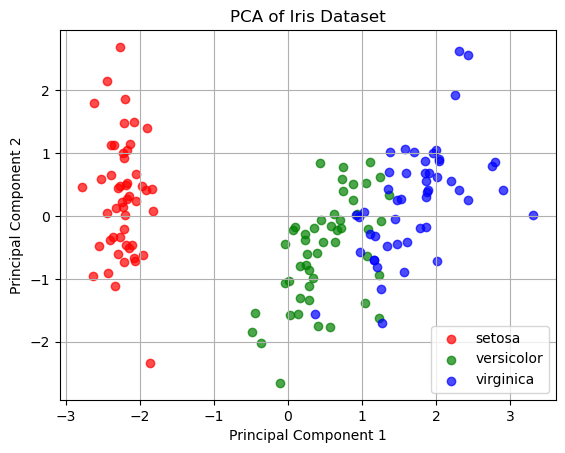

In [7]:
for i, target_name in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], alpha=0.7, label=target_name, color=colors[i])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.grid(True)
plt.show()

## Part 2: Stock Price Prediction Using Time Series Forecasting

### 1. Dataset Selection:

In [10]:
!pip install pmdarima
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [12]:
df = pd.read_csv("stock_price.csv")
print(df.head())

         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN              816123   

   %Deliverble  
0       0.3612  
1       0.3172  
2       0.2088  
3       0.2735  
4

### 2. Tasks to Perform

#### The Date column is converted to DateTime format for proper time-series handling. Missing values are filled using forward fill (ffill), and the Date is set as the index for analysis.

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df.fillna(method='ffill', inplace=True)
df.set_index('Date', inplace=True)
print("Dataset after preprocessing:\n", df.head())

Dataset after preprocessing:
                 Symbol Series  Prev Close    Open     High    Low   Last  \
Date                                                                       
2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

             Close    VWAP    Volume      Turnover  Trades  \
Date                                                         
2007-11-27  962.90  984.72  27294366  2.687719e+15     NaN   
2007-11-28  893.90  941.38   4581338  4.312765e+14     NaN   
2007-11-29  884.20  888.09   5124121  4.550658e+14     NaN   
2007-11-30  921.55  929.17   4609762  4.283257e+14     NaN   
2007-12-03  969.30  965.65   2977470  2.875200e+14     NaN   

  

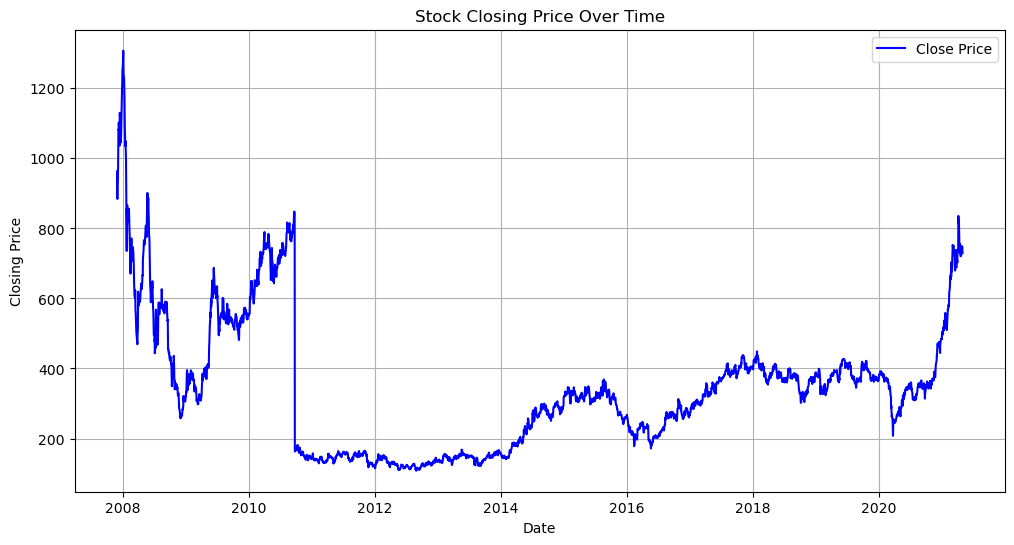

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], color='blue', label="Close Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Stock Closing Price Over Time")
plt.legend()
plt.grid(True)
plt.show()

#### The Close price is decomposed into trend, seasonality, and residual components using an additive model with a period of 30 days. The results are plotted to analyze patterns in the time series.

<Figure size 1200x800 with 0 Axes>

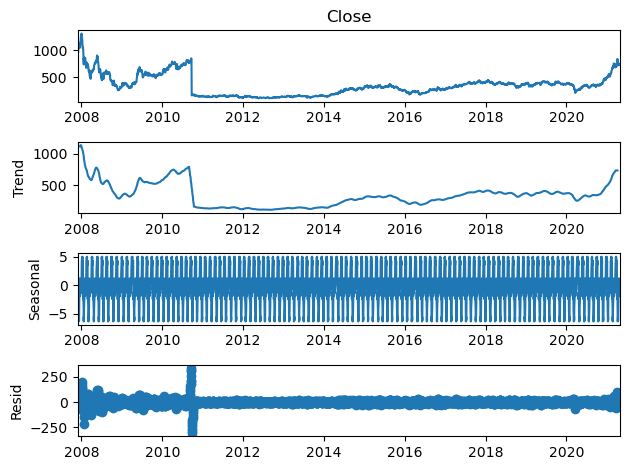

In [16]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=30)
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.show()

#### A lag feature is created by shifting the Close price by one day to capture past values. Moving averages over 7 and 30 days smooth short-term fluctuations and highlight trends. Missing values from lagging and rolling operations are removed.

In [17]:
df['Close_Lag1'] = df['Close'].shift(1)
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()
df.dropna(inplace=True)
print("Dataset after feature engineering:\n", df.head())

Dataset after feature engineering:
                 Symbol Series  Prev Close    Open    High     Low    Last  \
Date                                                                        
2011-06-01  MUNDRAPORT     EQ      161.45  162.10  165.70  161.25  163.50   
2011-06-02  MUNDRAPORT     EQ      164.00  164.00  165.15  160.15  161.15   
2011-06-03  MUNDRAPORT     EQ      161.25  161.50  162.80  159.20  161.00   
2011-06-06  MUNDRAPORT     EQ      161.05  160.50  161.10  159.05  160.00   
2011-06-07  MUNDRAPORT     EQ      159.85  159.85  162.75  156.35  157.00   

             Close    VWAP   Volume      Turnover   Trades  \
Date                                                         
2011-06-01  164.00  164.08  2574106  4.223703e+13  19171.0   
2011-06-02  161.25  162.17  1699298  2.755678e+13  16176.0   
2011-06-03  161.05  161.02  1185817  1.909361e+13  14810.0   
2011-06-06  159.85  160.09   546378  8.746905e+12   7071.0   
2011-06-07  157.25  158.52  2193466  3.477027e+13  1

#### The data is split into training (first 80%) and testing (remaining 20%), and an ARIMA model is fitted to the training set for forecasting.

In [18]:
auto_arima_model = auto_arima(df['Close'], seasonal=False, trace=True)
p, d, q = auto_arima_model.order
print(f"Best ARIMA order: p={p}, d={d}, q={q}")

train_size = int(len(df) * 0.8)  
train, test = df['Close'][:train_size], df['Close'][train_size:]

arima_model = ARIMA(train, order=(p, d, q))
arima_result = arima_model.fit()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16726.205, Time=7.32 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16742.192, Time=0.18 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16741.939, Time=0.50 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16741.850, Time=0.64 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16742.629, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.36 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=16740.909, Time=2.19 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=16744.642, Time=5.25 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=16744.834, Time=4.64 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16742.991, Time=1.61 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=16742.707, Time=2.85 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=16742.548, Time=2.52 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=16747.060, Time=6.65 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=16726.732, Time=3.18 sec

Best model:  ARIMA(2,1,2

In [19]:
predictions = arima_result.forecast(steps=len(test))
test_df = test.to_frame()
test_df['Predicted_Close'] = predictions.values

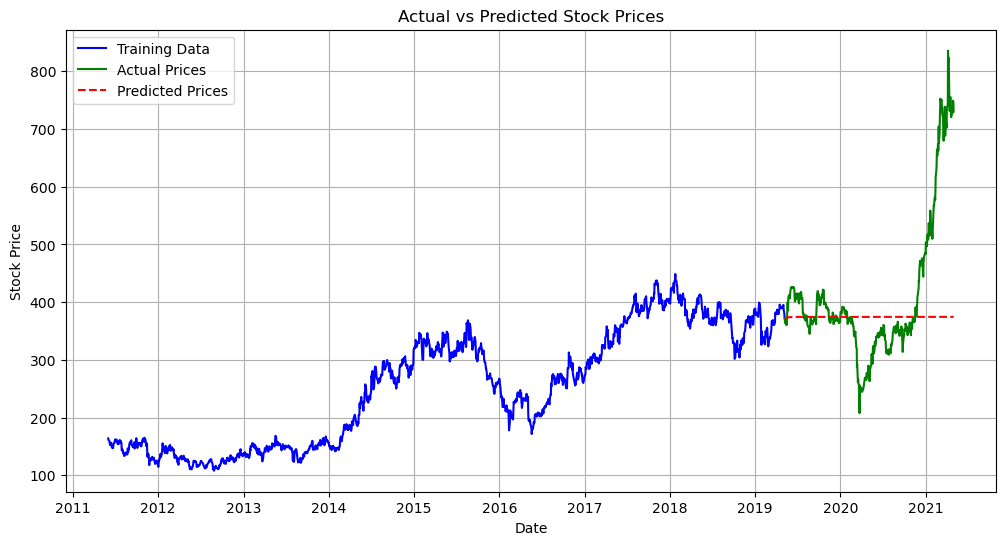

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(train, label="Training Data", color='blue')
plt.plot(test.index, test, label="Actual Prices", color='green')
plt.plot(test.index, test_df['Predicted_Close'], label="Predicted Prices", color='red', linestyle='dashed')
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted Stock Prices")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
mae = mean_absolute_error(test, test_df['Predicted_Close'])
rmse = np.sqrt(mean_squared_error(test, test_df['Predicted_Close']))
mape = np.mean(np.abs((test - test_df['Predicted_Close']) / test)) * 100

print(f"Model Evaluation Metrics:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%")

Model Evaluation Metrics:
MAE: 74.99
RMSE: 126.89
MAPE: 15.66%
